# Comparing two datasets without regridding

This is the example the hub exists for.

Comparing a model run against a reanalysis normally starts with a day of
grid work: find the two grids, pick a common target, choose a remapping
scheme, generate weights, argue about conservative versus bilinear, and
discover afterwards that the difference field has a suspicious pattern at
the poles. The comparison itself is the easy part and it is never where the
time goes.

Both stores below are HEALPix, nested, on the same sphere. Cell `i` at level
5 is the same patch of the planet in both files, by construction, because
the grid is defined by the index rather than agreed by convention. So the
grid work is not simplified here. It is absent.

*The figure is saved with this notebook. Run the cells in order, from the top, to compute it again. The same example on the web: [Comparing two datasets without regridding](https://waterpark.dkrz.de/docs/examples/08_cross_dataset/).*

## The two stores

ECMWF's ERA5 reanalysis and the nextGEMS ICON cycle-4 run, from different
institutions through different pipelines, both published at HEALPix level
5. One is monthly, the other daily.

In [ ]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from healpix_geo import nested

S3 = {"anon": True, "endpoint_url": "https://s3.waterpark.dkrz.de"}
ERA5 = "s3://reanalysis/healpix/era5/P1M/level_5.zarr"
MODEL = "s3://nextgems/healpix/ngc4008/P1D/level_5.zarr"

era5 = xr.open_zarr(ERA5, storage_options=S3, chunks=None)
model = xr.open_zarr(MODEL, storage_options=S3, chunks=None)

for name, store in (("ERA5", era5), ("ngc4008", model)):
    print(
        f"{name:8s} level {store.attrs.get('healpix_level', '7')}, "
        f"{store.sizes['cell']:6d} cells, "
        f"{store.sizes['time']:6d} time steps"
    )

assert era5.sizes["cell"] == model.sizes["cell"]

## Three things have to line up

Variable, level and time. Only the middle one is a grid problem, and it is
the one that turns out to be free.

**Variable.** Both of these happen to use CMOR names, so `tas` is `tas` in
each. Do not count on it: the hub carries stores using ECMWF short names
and stores using native model names, and no amount of clever indexing
fixes a naming difference. That is a lookup table you write once.

**Level.** Equal, so there is nothing to do. Had the model been a level
finer, `model.coarsen(cell=4).mean()` would have been the entire
adjustment, as in the [previous example](https://waterpark.dkrz.de/docs/examples/07_pyramid_levels/).

**Time.** A monthly mean series and a daily mean series, both reduced to
one annual mean. Neither reduction is a plain `.mean("time")`: months have
different lengths, so the monthly series needs day weights, and the daily
series needs a check that the year is actually complete.

In [ ]:
YEAR = "2021"

era5_months = era5["tas"].sel(time=YEAR)
model_days = model["tas"].sel(time=YEAR)

days_in_month = era5_months["time"].dt.days_in_month
era5_mean = ((era5_months * days_in_month).sum("time") / days_in_month.sum()).load()
model_mean = model_days.mean("time").load()

print(f"{era5_months.sizes['time']} ERA5 months, {model_days.sizes['time']} model days")
print(
    f"month lengths {int(days_in_month.min())}-{int(days_in_month.max())}, "
    f"summing to {int(days_in_month.sum())}"
)

## The comparison

And that is it. Two arrays of 12288 numbers each, describing the same
12288 patches of the Earth, so subtraction is defined. No weights file, no
interpolation, no target grid to agree on, and nothing that needed to be
told where the poles are.

In [ ]:
bias = model_mean.values - era5_mean.values

print(f"mean bias  {bias.mean():+.2f} K")
print(f"rms  bias  {np.sqrt((bias**2).mean()):.2f} K")
print(f"worst cell {np.abs(bias).max():.2f} K")

The global mean bias is an unweighted mean over cells, and correct for the
reason given in the [equal area example](https://waterpark.dkrz.de/docs/examples/02_global_mean/).

## The plot

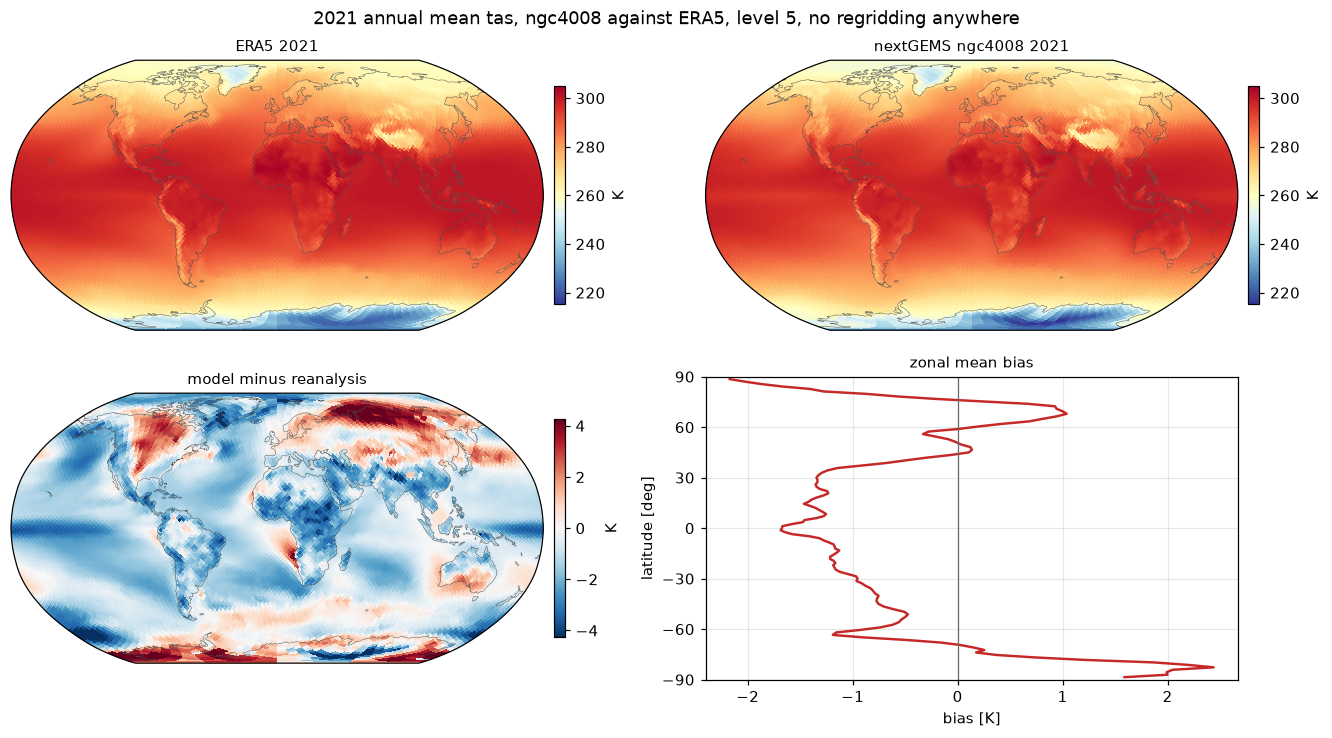

In [ ]:
level = era5.attrs["healpix_level"]
latitude = era5["latitude"].values
_, rings = np.unique(np.round(latitude, 8), return_inverse=True)
ring_lat = np.array([latitude[rings == r][0] for r in range(rings.max() + 1)])
zonal_bias = np.array([bias[rings == r].mean() for r in range(rings.max() + 1)])


def rasterize(values, nlon=1080, nlat=540):
    lon = np.linspace(-180, 180, nlon)
    lat = np.linspace(90, -90, nlat)
    mesh_lon, mesh_lat = np.meshgrid(lon, lat)
    cells = nested.lonlat_to_healpix(mesh_lon.ravel(), mesh_lat.ravel(), level)
    return np.asarray(values)[cells.astype("int64")].reshape(mesh_lat.shape), lon, lat


vmin = float(min(era5_mean.values.min(), model_mean.values.min()))
vmax = float(max(era5_mean.values.max(), model_mean.values.max()))
span = float(np.percentile(np.abs(bias), 99))

fig = plt.figure(figsize=(12, 6.6), layout="constrained")

for index, (title, values) in enumerate(
    [
        (f"ERA5 {YEAR}", era5_mean.values),
        (f"nextGEMS ngc4008 {YEAR}", model_mean.values),
    ],
    start=1,
):
    raster, lon, lat = rasterize(values)
    ax = fig.add_subplot(2, 2, index, projection=ccrs.Robinson())
    ax.coastlines(linewidth=0.3, color="0.3")
    ax.set_global()
    mesh = ax.pcolormesh(
        lon,
        lat,
        raster,
        cmap="RdYlBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(title, fontsize=10)
    fig.colorbar(mesh, ax=ax, shrink=0.72, pad=0.02, label="K")

raster, lon, lat = rasterize(bias)
ax = fig.add_subplot(2, 2, 3, projection=ccrs.Robinson())
ax.coastlines(linewidth=0.3, color="0.3")
ax.set_global()
mesh = ax.pcolormesh(
    lon,
    lat,
    raster,
    cmap="RdBu_r",
    vmin=-span,
    vmax=span,
    shading="auto",
    transform=ccrs.PlateCarree(),
)
ax.set_title("model minus reanalysis", fontsize=10)
fig.colorbar(mesh, ax=ax, shrink=0.72, pad=0.02, label="K")

ax_zonal = fig.add_subplot(2, 2, 4)
ax_zonal.plot(zonal_bias, ring_lat, color="#c62828", lw=1.6)
ax_zonal.axvline(0.0, color="0.4", lw=0.8)
ax_zonal.set_yticks(np.arange(-90, 91, 30))
ax_zonal.set_ylim(-90, 90)
ax_zonal.set_xlabel("bias [K]")
ax_zonal.set_ylabel("latitude [deg]")
ax_zonal.set_title("zonal mean bias", fontsize=10)
ax_zonal.grid(alpha=0.3)

fig.suptitle(
    f"{YEAR} annual mean tas, ngc4008 against ERA5, level {level}, "
    "no regridding anywhere",
    fontsize=12,
)

fig.savefig("08_cross_dataset.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

## What is left to be careful about

The grid stopped being a problem, which means the remaining problems are
the interesting ones, and they are all scientific:

- **The two `tas` fields are not the same thing.** ERA5's is a diagnostic
  from a reanalysis with data assimilation; the model's is a diagnostic
  from a free-running simulation. A free run has no reason to reproduce a
  particular year's weather, so day-to-day agreement is not expected and
  only the climatology is worth reading.
- **One year is a short climatology.** The bias field contains a real
  model bias plus one realisation of internal variability, and the figure
  cannot tell you which is which. Widen `YEAR` before drawing any
  conclusion from it.
- **Sea ice and orography dominate the extremes.** The largest values in
  the difference map are where the two datasets disagree about what is at
  the surface, not where they disagree about the atmosphere. That is worth
  masking before quoting a number.

Those are questions about climate, not about file formats, which is the
point.